In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import math

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
sp500_returns = """
2020	 18.38
2019	 31.74
2018	 -4.41
2017	 21.94
2016	 11.93
2015	  1.31
2014	 13.81
2013	 32.43
2012	 15.88
2011	  2.07
2010	 14.87
2009	 27.11
2008	-37.22
2007	  5.46
2006	 15.74
2005	  4.79
2004	 10.82
2003	 28.72
2002	-22.27
2001	-11.98
2000	 -9.11
1999	 21.11
1998	 28.73
1997	 33.67
1996	 23.06
1995	 38.02
1994	  1.19
1993	 10.17
1992	  7.60
1991	 30.95
1990	 -3.42
1989	 32.00
1988	 16.64
1987	  5.69
1986	 19.06
1985	 32.24
1984	  5.96
1983	 23.13
1982	 21.22
1981	 -5.33
1980	 32.76
1979	 18.69
1978	  6.41
1977	 -7.78
1976	 24.20
1975	 38.46
1974	-26.95
1973	-15.03
1972	 19.15
1971	 14.54
1970	  3.60
1969	 -8.63
1968	 11.03
1967	 24.45
1966	-10.36
1965	 12.45
1964	 16.59
1963	 23.04
1962	 -9.20
1961	 28.51
1960	 -0.74
1959	 11.59
1958	 43.40
1957	 -9.30
1956	  6.38
1955	 28.22
1954	 55.99
1953	 -0.80
1952	 18.35
1951	 23.10
1950	 34.28
1949	 15.96
1948	  9.51
1947	  2.56
1946	-12.05
1945	 39.35
1944	 19.67
1943	 23.60
1942	 21.74
1941	 -9.09
1940	 -8.91
1939	  2.98
1938	 17.50
1937	-32.11
1936	 32.55
1935	 54.93
1934	 -8.01
1933	 56.79
1932	 -5.81
1931	-44.20
1930	-22.72
1929	 -9.46
1928	 47.57
1927	 37.10
1926	 11.51
1925	 25.83
1924	 27.10
1923	  5.45
1922	 29.07
1921	 10.15
1920	-13.95
1919	 19.67
1918	 18.21
1917	-18.62
1916	  8.12
1915	 31.20
1914	 -5.39
1913	 -4.73
1912	  7.18
1911	  3.52
1910	 -3.39
1909	 16.15
1908	 39.47
1907	-24.21
1906	  0.64
1905	 21.29
1904	 32.16
1903	-17.09
1902	  8.28
1901	 19.45
"""

all_returns = []
for row in sp500_returns.split('\n'):
    if not row.strip():
        continue
    _, r = row.split()
    all_returns.append(float(r) / 100)


### Distribution of Ending Wealth

SPX vs. Store-of-Value vs. Insurance

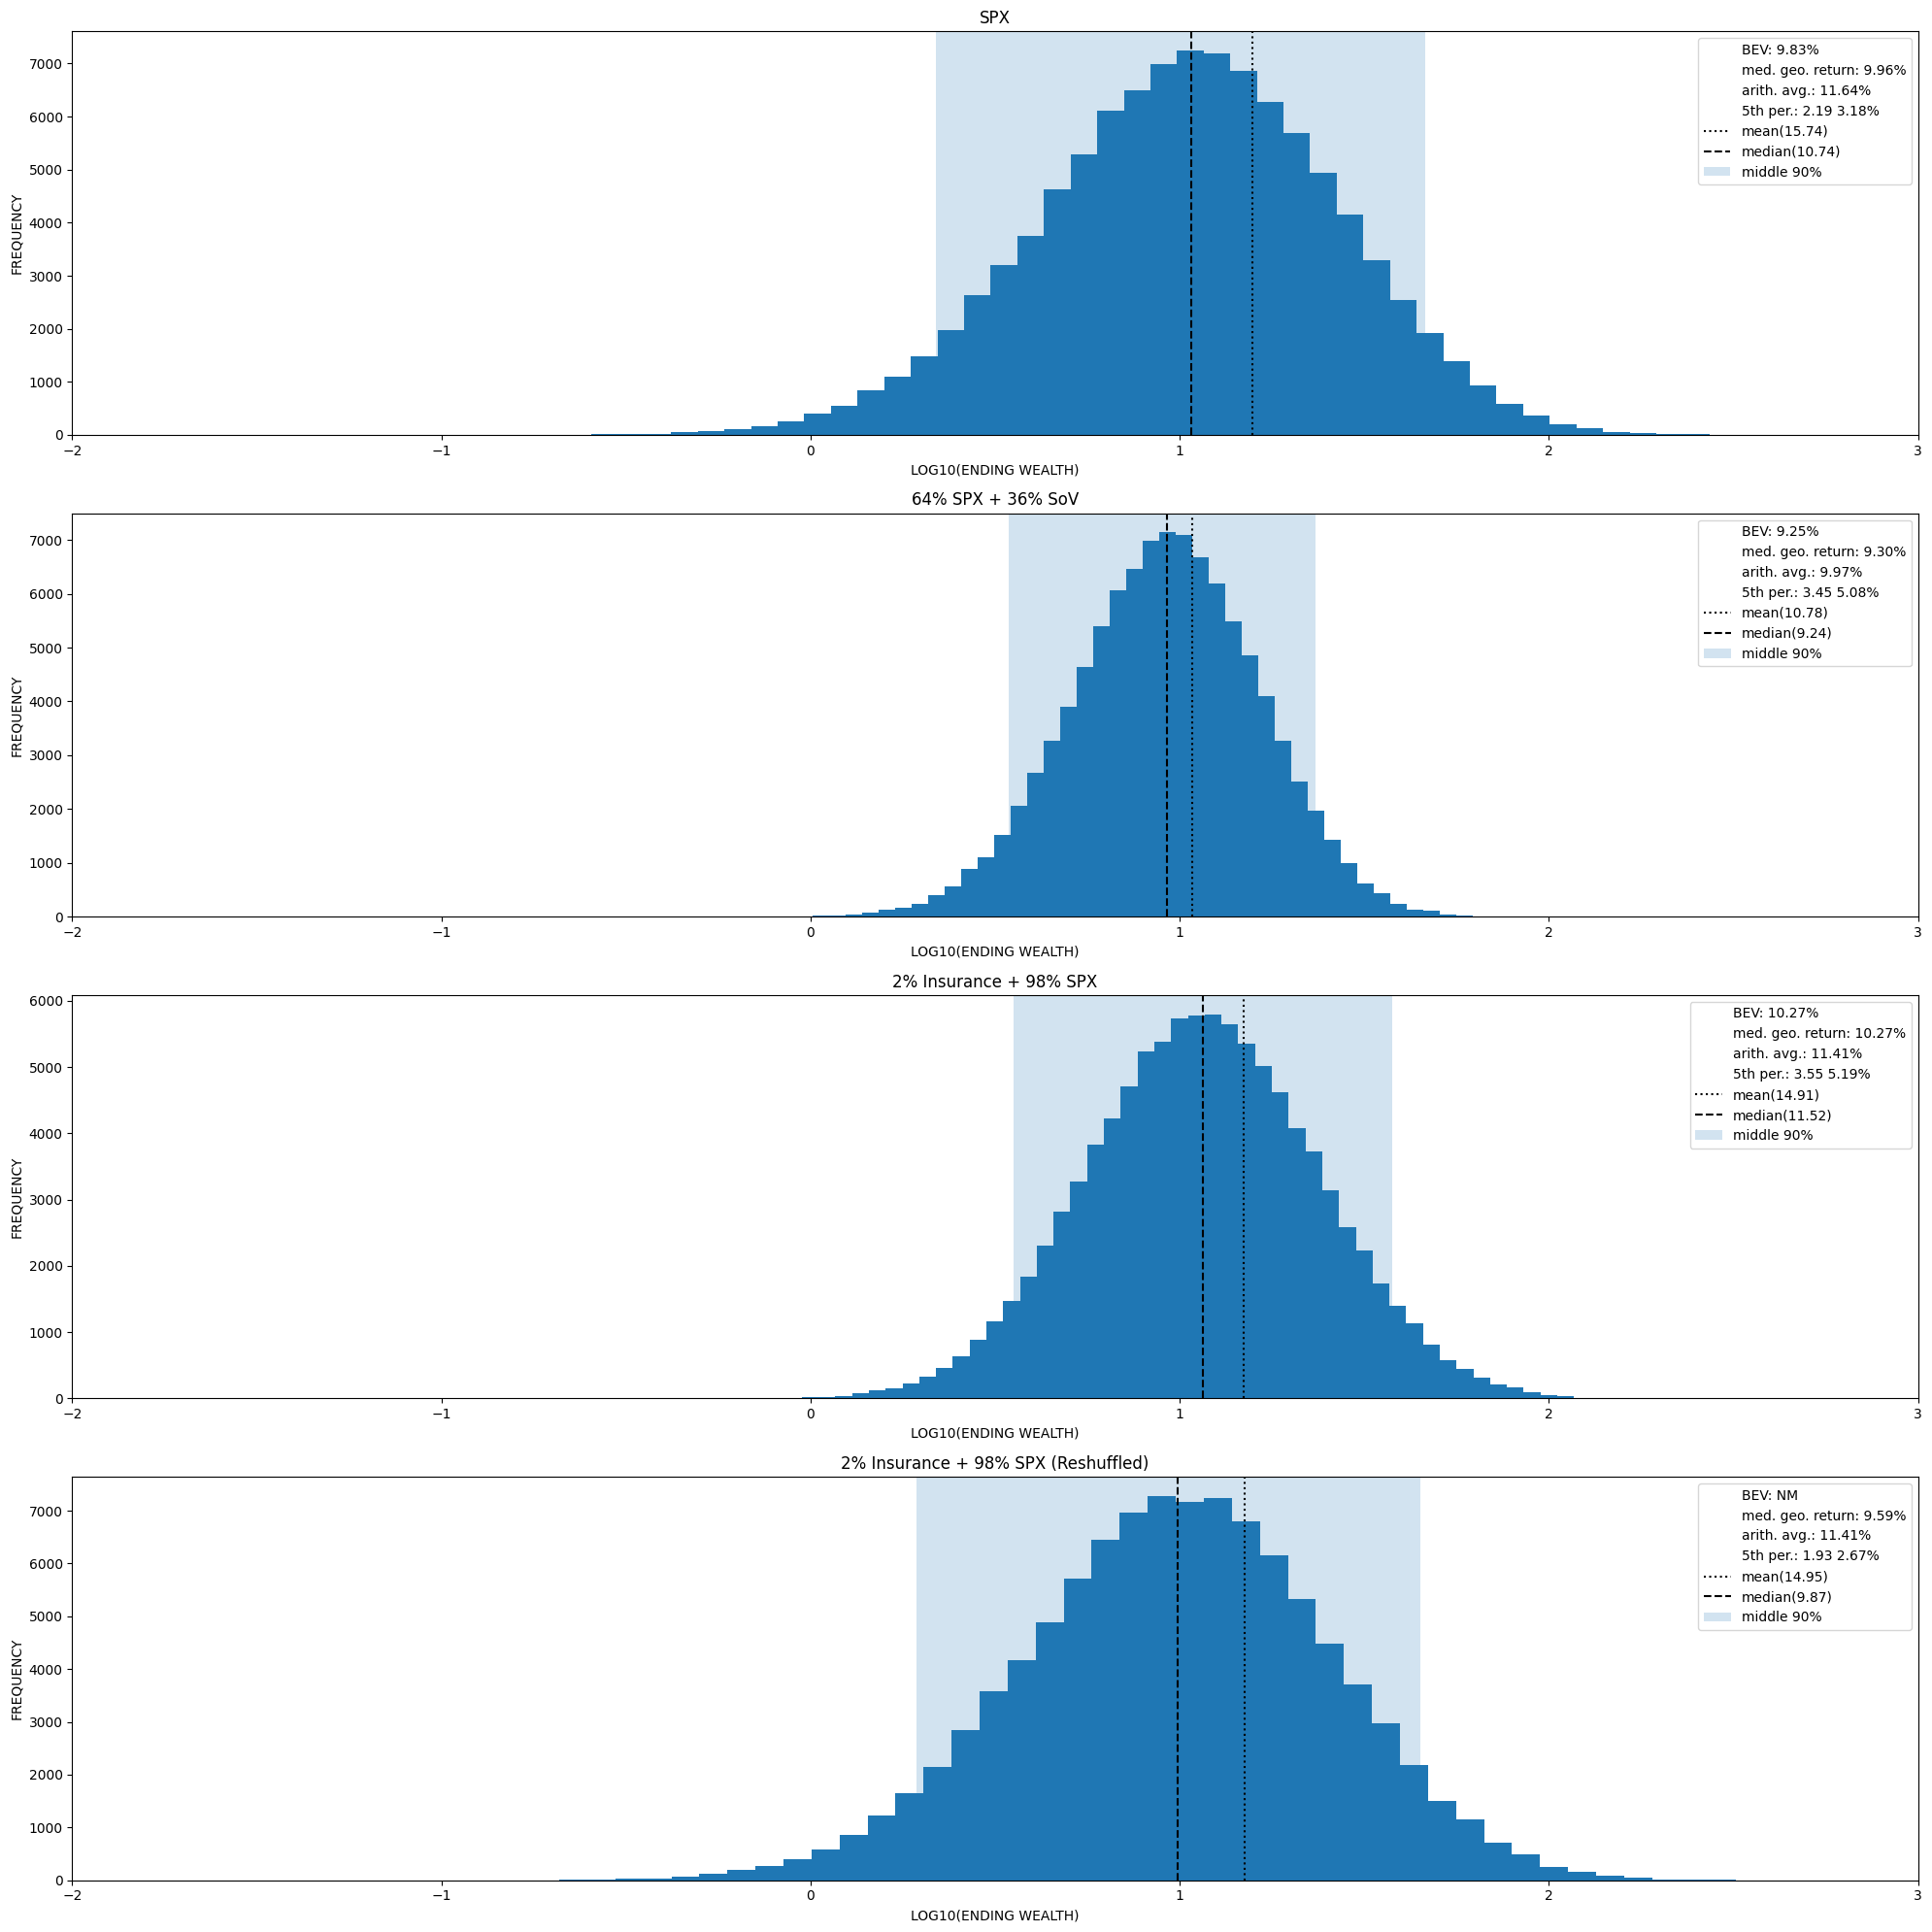

In [15]:
payoffs = np.asarray(all_returns)

samples = 100000
bets = 25
store_of_value_return = 1.07 # 7% percent return

random_paths = np.random.randint(0, len(payoffs), (samples, bets))

fig, (subfig1, subfig2, subfig3, subfig4) = plt.subplots(4, 1, figsize=(20, 20))

# ------- All In
ending_wealths = np.prod(1 + payoffs[random_paths], axis=1)
mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
bev = np.exp(np.mean(np.log(1+payoffs))) - 1
median_geometric_return = median ** (1 / bets) - 1

arithmetic_avg = np.mean(1 + payoffs) - 1

subfig1.hist(ending_wealth_log, bins=60)
subfig1.set_xlim(-2, 3)
# legend-only text entries
subfig1.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig1.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig1.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig1.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f} {(np.power(np.power(10, p5), 1/bets) - 1)* 100:.2f}%')

subfig1.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig1.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig1.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig1.set_title("SPX")
subfig1.set_xlabel("LOG10(ENDING WEALTH)")
subfig1.set_ylabel("FREQUENCY")
subfig1.legend()

# ------- 36% cash
cash_ratio = 0.36

ending_wealths = np.prod(
    (1-cash_ratio) * (1 + payoffs[random_paths]) + cash_ratio * store_of_value_return,
    axis=1)

mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
bev = np.exp(np.mean(np.log(cash_ratio * store_of_value_return+(1-cash_ratio)*(1+payoffs)))) - 1
median_geometric_return = median ** (1 / bets) - 1
arithmetic_avg = np.mean(cash_ratio*store_of_value_return + (1-cash_ratio) * (1+payoffs)) - 1

subfig2.hist(ending_wealth_log, bins=60)
subfig2.set_xlim(-2, 3)
# legend-only text entries
subfig2.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig2.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig2.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig2.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f} {(np.power(np.power(10, p5), 1/bets) - 1)* 100:.2f}%')

subfig2.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig2.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig2.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig2.set_title("64% SPX + 36% SoV")
subfig2.set_xlabel("LOG10(ENDING WEALTH)")
subfig2.set_ylabel("FREQUENCY")
subfig2.legend()

# ------- Insurance 2%
insurance_cost = 0.02
# make sure the arithmetic average return of the insurance is zero
insurance_threshold = -0.15
insurance_payoff = payoffs.size/np.sum(payoffs <= insurance_threshold)

main_bet_returns = payoffs[random_paths]
insurance_returns = np.zeros_like(main_bet_returns)
insurance_returns[main_bet_returns <= insurance_threshold] = insurance_payoff

ending_wealths = np.prod(
    (1-insurance_cost) * (1+main_bet_returns) + insurance_cost * insurance_returns,
    axis=1)

mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
median_geometric_return = median ** (1 / bets) - 1

insured_payoffs = np.zeros_like(payoffs)
insured_payoffs[payoffs < insurance_threshold] = insurance_payoff
arithmetic_avg = np.mean(insurance_cost * insured_payoffs + (1-insurance_cost) * (1+payoffs)) - 1

bev = np.exp(np.mean(np.log((1-insurance_cost)*(payoffs+1) + insurance_cost*insured_payoffs))) - 1

subfig3.hist(ending_wealth_log, bins=60)
subfig3.set_xlim(-2, 3)
# legend-only text entries
subfig3.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig3.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig3.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig3.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f} {(np.power(np.power(10, p5), 1/bets) - 1)* 100:.2f}%')

subfig3.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig3.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig3.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig3.set_title("2% Insurance + 98% SPX")
subfig3.set_xlabel("LOG10(ENDING WEALTH)")
subfig3.set_ylabel("FREQUENCY")
subfig3.legend()

# ------- Insurance 2% Reshuffled
main_bet_returns = payoffs[random_paths]
insurance_returns = np.zeros_like(main_bet_returns)
insurance_returns[payoffs[insurance_random_paths] <= insurance_threshold] = insurance_payoff

ending_wealths = np.prod(
    (1-insurance_cost) * (1+main_bet_returns) + insurance_cost * insurance_returns,
    axis=1)

mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
median_geometric_return = median ** (1 / bets) - 1

insured_payoffs = np.zeros_like(payoffs)
insured_payoffs[payoffs < insurance_threshold] = insurance_payoff
arithmetic_avg = np.mean(insurance_cost * insured_payoffs + (1-insurance_cost) * (1+payoffs)) - 1

subfig4.hist(ending_wealth_log, bins=60)
subfig4.set_xlim(-2, 3)
# legend-only text entries
subfig4.plot([], [], ' ', label=f'BEV: NM')
subfig4.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig4.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig4.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f} {(np.power(np.power(10, p5), 1/bets) - 1)* 100:.2f}%')

subfig4.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig4.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig4.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig4.set_title("2% Insurance + 98% SPX (Reshuffled)")
subfig4.set_xlabel("LOG10(ENDING WEALTH)")
subfig4.set_ylabel("FREQUENCY")
subfig4.legend()

fig.tight_layout()
plt.show()


### Optimal Cartoon Safe Haven Allocation Sizes
This might take a long time to run.

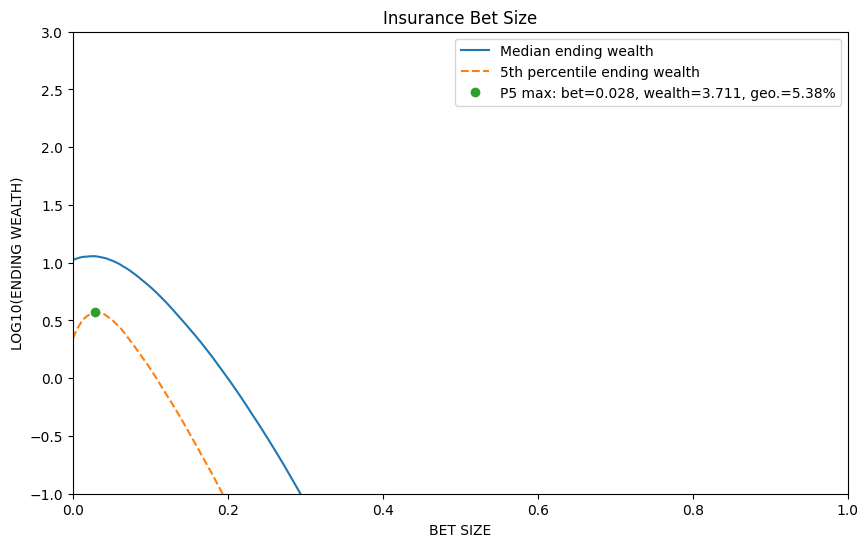

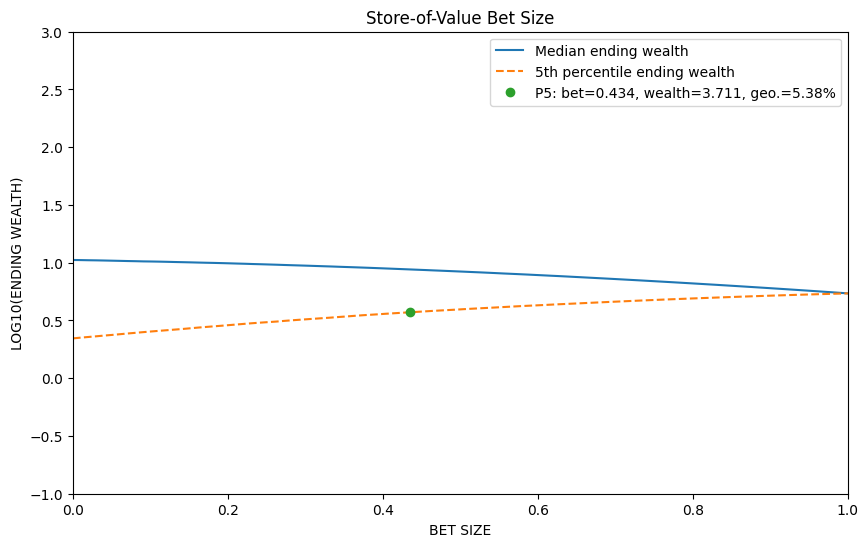

In [9]:

eps = 1e-12

sim_samples = 10000
# all simulation share the same random path
main_bet_returns = payoffs[np.random.randint(0, len(payoffs), (sim_samples, bets))]

# insurance
# i am cheating here, because i knew from the book that the relevant sizes lies between 0~40%
# otherwise we need way to many steps here
ins_bet_sizes = np.linspace(0, 0.4, 100)
insured_payoffs = np.zeros_like(main_bet_returns)
insured_payoffs[main_bet_returns <= insurance_threshold] = insurance_payoff

insurance_expanded = np.reshape(ins_bet_sizes, (-1, 1, 1))
ending_wealths = np.prod((1-insurance_expanded) * (1+main_bet_returns) + insurance_expanded * insured_payoffs, axis=2)

ending_wealths_medians = np.median(ending_wealths, axis=1)
ending_wealths_p5 = np.percentile(ending_wealths, 5, axis=1)

# max of 5th percentile curve
idx_max_p5 = np.argmax(ending_wealths_p5)
best_bet_p5 = ins_bet_sizes[idx_max_p5]
best_value_p5 = ending_wealths_p5[idx_max_p5]

plt.figure(figsize=(10,6))
plt.xlim(0, 1)
plt.ylim(-1, 3)
plt.plot(ins_bet_sizes, np.log10(np.clip(ending_wealths_medians, eps, None)),
         linestyle='solid',
         label='Median ending wealth')

plt.plot(ins_bet_sizes, np.log10(np.clip(ending_wealths_p5, eps, None)),
         linestyle='dashed',
         label='5th percentile ending wealth')

# mark the max points
plt.plot(best_bet_p5, np.log10(best_value_p5), 'o',
         label=f'P5 max: bet={best_bet_p5:.3f}, wealth={best_value_p5:.3f}, geo.={(np.power(best_value_p5, 1/bets)-1) * 100:.2f}%')

plt.xlabel("BET SIZE")
plt.ylabel("LOG10(ENDING WEALTH)")
plt.title("Insurance Bet Size")
plt.legend()

plt.show()

# store of value
bet_sizes = np.linspace(0, 1, 100)

sov_alloction_expanded = np.reshape(bet_sizes, (-1, 1, 1))
ending_wealths = np.prod((1-sov_alloction_expanded) * (1+main_bet_returns) + sov_alloction_expanded * store_of_value_return, axis=2)
ending_wealths_medians = np.median(ending_wealths, axis=1)
ending_wealths_p5 = np.percentile(ending_wealths, 5, axis=1)

plt.figure(figsize=(10,6))
plt.ylim(-1, 3)
plt.xlim(0, 1)
plt.plot(bet_sizes, np.log10(ending_wealths_medians),
         linestyle='solid',
         label='Median ending wealth')

plt.plot(bet_sizes, np.log10(ending_wealths_p5),
         linestyle='dashed',
         label='5th percentile ending wealth')

# we need to find the bet size with a p5 return closest to max p5 of insurance strategy.
closest_idx = np.abs(ending_wealths_p5 - best_value_p5).argmin()

plt.plot(bet_sizes[closest_idx], np.log10(ending_wealths_p5[closest_idx]), 'o',
         label=f'P5: bet={bet_sizes[closest_idx]:.3f}, wealth={best_value_p5:.3f}, geo.={(np.power(best_value_p5, 1/bets)-1) * 100:.2f}%')

plt.xlabel("BET SIZE")
plt.ylabel("LOG10(ENDING WEALTH)")
plt.title("Store-of-Value Bet Size")
plt.legend()
plt.show()